# Student Performance
The goal of this project is centered around the prediction of student performance levels by using features within the dataset. This project aims to predict student academic performance using machine learning techniques. The performance levels for studectns are classified into distinct classes denoted as 'H' (High), 'M' (Medium), and 'L' (Low), providing a framework for gauging academic achievement. The dataset  "xAPI-Edu-Data" is used for this project and was obtained from Kaggle.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import label_binarize
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc, roc_auc_score

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

import tensorflow as tf


import warnings
warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv('xAPI-Edu-Data.csv')
df.head()

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M


In [ ]:
print(df.describe())

       raisedhands  VisITedResources  AnnouncementsView  Discussion
count   480.000000        480.000000         480.000000  480.000000
mean     46.775000         54.797917          37.918750   43.283333
std      30.779223         33.080007          26.611244   27.637735
min       0.000000          0.000000           0.000000    1.000000
25%      15.750000         20.000000          14.000000   20.000000
50%      50.000000         65.000000          33.000000   39.000000
75%      75.000000         84.000000          58.000000   70.000000
max     100.000000         99.000000          98.000000   99.000000


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

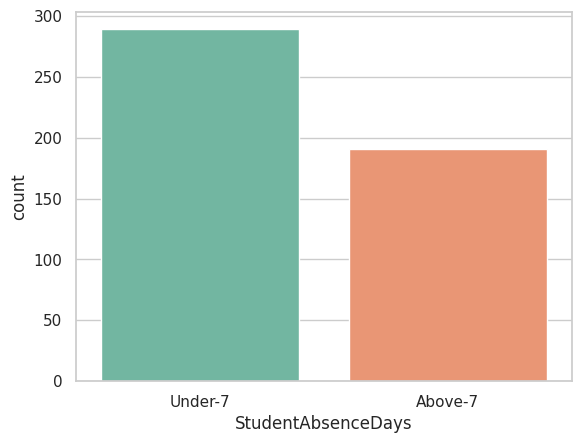

In [ ]:
sns.countplot(x='StudentAbsenceDays', data=df, palette='Set2')
plt.show()

<Axes: xlabel='Class', ylabel='count'>

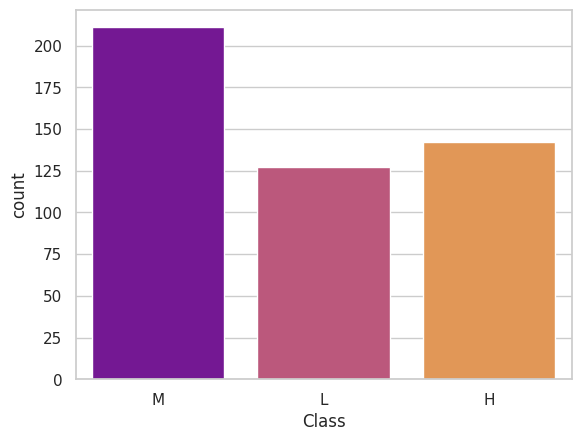

In [ ]:
# Count of students of each class
sns.countplot(x='Class',data=df, palette='plasma')

<Axes: xlabel='Class', ylabel='count'>

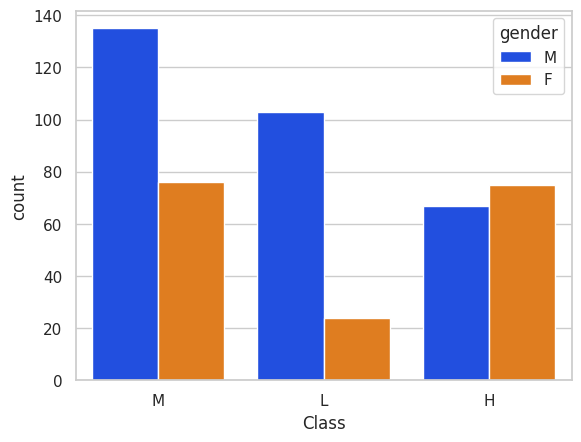

In [ ]:
# Student class by gender
sns.countplot(x='Class',hue='gender',data=df,palette='bright')

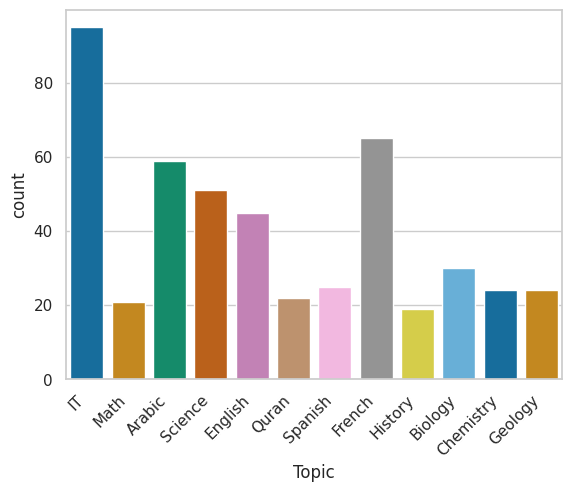

In [ ]:
#breakdown by class
sns.countplot(x="Topic", data=df, palette='colorblind');
plt.xticks(rotation=45, ha='right')
plt.show()

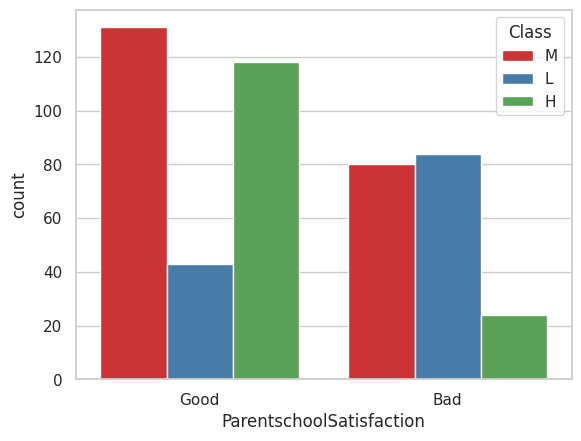

In [ ]:
# Parent Satisfaction
sns.countplot(x='ParentschoolSatisfaction',data = df, hue='Class',palette='Set1')
plt.show()

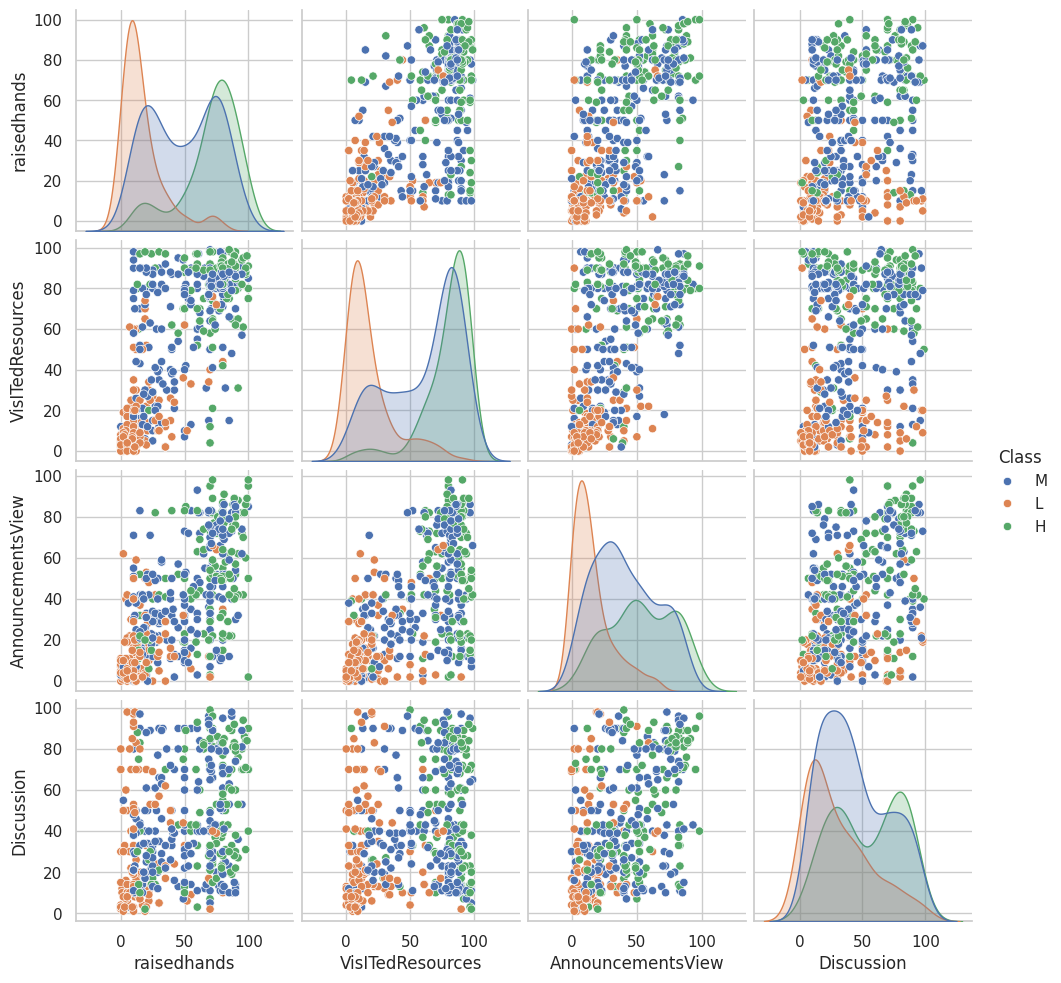

In [ ]:
# Pairplot
sns.pairplot(df, hue='Class', diag_kind='kde')
plt.show()

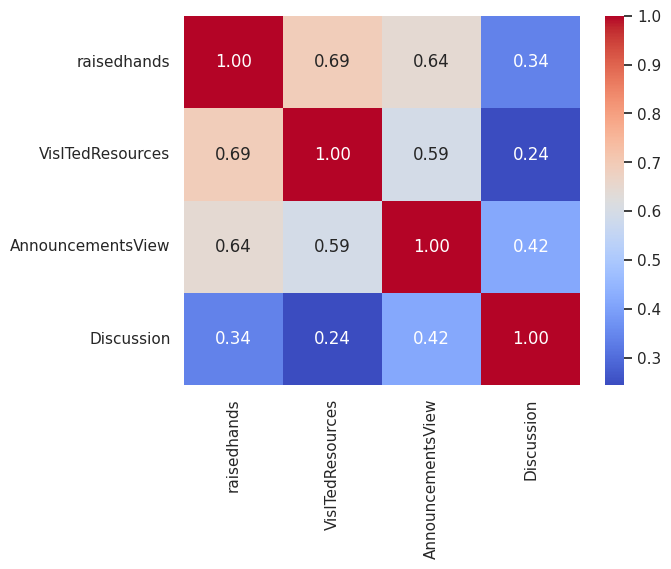

In [ ]:
# Correlation heatmap
corr_matrix = df[['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.show()

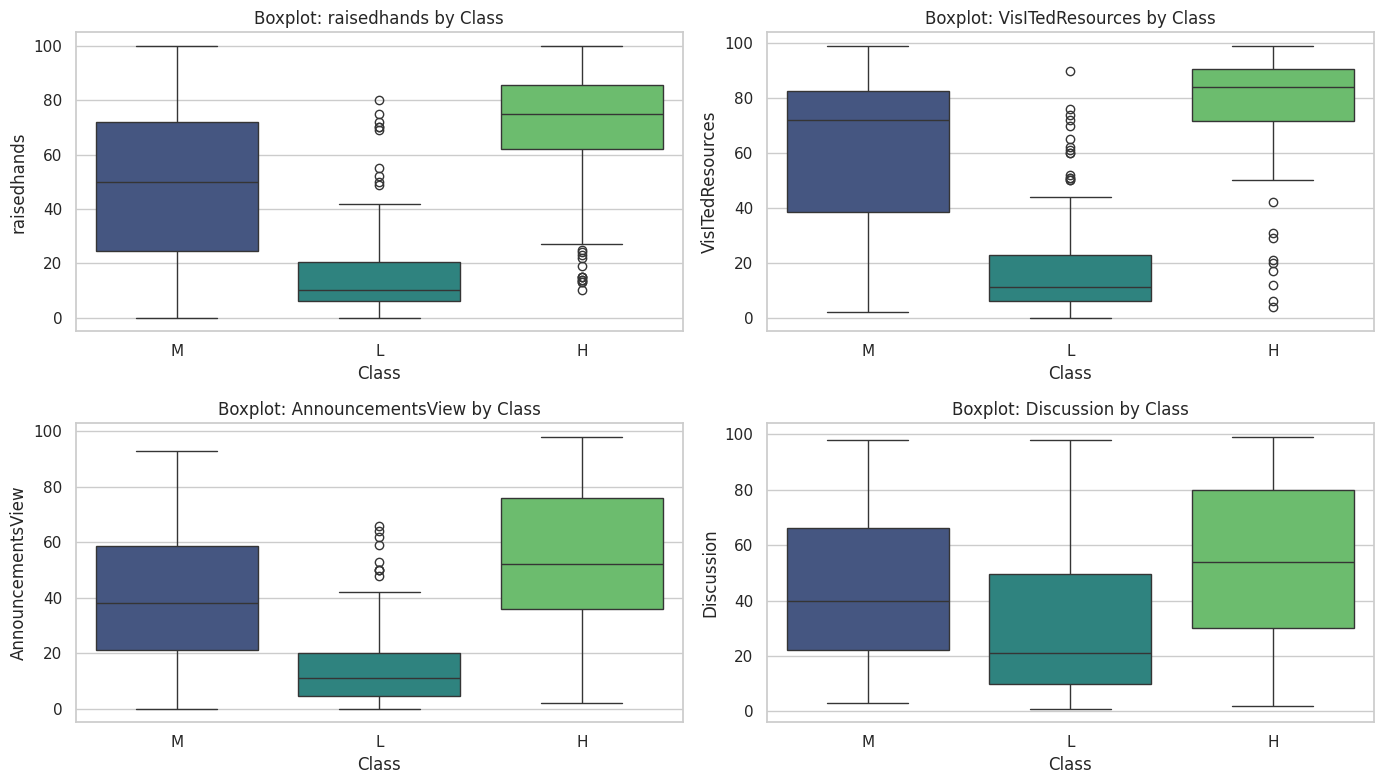

In [ ]:
sns.set(style="whitegrid")

info = ['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

plt.figure(figsize=(14, 8))
for i, var in enumerate(info , 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Class', y=var, data=df, palette='viridis')
    plt.title(f'Boxplot: {var} by Class')

# Adjust layout
plt.tight_layout()
plt.show()

In [ ]:
df.isnull().sum()

,0
gender,0
NationalITy,0
PlaceofBirth,0
StageID,0
GradeID,0
SectionID,0
Topic,0
Semester,0
Relation,0
raisedhands,0


In [ ]:
columns = ['NationalITy', 'PlaceofBirth', 'StageID', 'GradeID', 'SectionID', 'Topic', 'Semester', 'Relation', 'ParentAnsweringSurvey', 'ParentschoolSatisfaction', 'StudentAbsenceDays']
df['gender'] = df['gender'].map({'M': 0, 'F': 1})

df = pd.get_dummies(df, columns=columns)
df.head()

,gender,raisedhands,VisITedResources,AnnouncementsView,Discussion,Class,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,...,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7
0,0,15,16,2,20,M,False,False,False,False,...,True,False,True,False,False,True,False,True,False,True
1,0,20,20,3,25,M,False,False,False,False,...,True,False,True,False,False,True,False,True,False,True
2,0,10,7,0,30,L,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False
3,0,30,25,5,35,L,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False
4,0,40,50,12,50,M,False,False,False,False,...,True,False,True,False,True,False,True,False,True,False


In [ ]:
Level = df['Class']

Data = df[['gender', 'raisedhands', 'VisITedResources', 'AnnouncementsView',
                    'Discussion', 'StudentAbsenceDays_Above-7','StudentAbsenceDays_Under-7']]


# Scaling and Train Test Split

In [ ]:
scaler = StandardScaler()
scaler.fit(Data)
scaled = scaler.transform(Data)

X = scaled
y = Level

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


# Regression

Logistic Regression Accuracy: 0.7917
Confusion Matrix:
[[16  0  6]
 [ 0 26  0]
 [ 7  7 34]]
Classification Report:
              precision    recall  f1-score   support

           H       0.70      0.73      0.71        22
           L       0.79      1.00      0.88        26
           M       0.85      0.71      0.77        48

    accuracy                           0.79        96
   macro avg       0.78      0.81      0.79        96
weighted avg       0.80      0.79      0.79        96



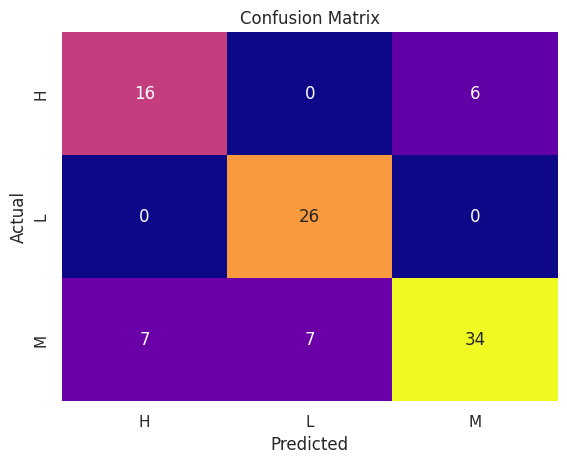

In [ ]:
logreg_model = LogisticRegression()
logreg_model.fit(X_train, y_train)

y_pred = logreg_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="plasma", cbar=False,
            xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# Random Forest

Accuracy: 0.8020833333333334

Confusion Matrix:
[[16  0  6]
 [ 0 24  2]
 [ 6  5 37]]

Classification Report:
              precision    recall  f1-score   support

           H       0.73      0.73      0.73        22
           L       0.83      0.92      0.87        26
           M       0.82      0.77      0.80        48

    accuracy                           0.80        96
   macro avg       0.79      0.81      0.80        96
weighted avg       0.80      0.80      0.80        96



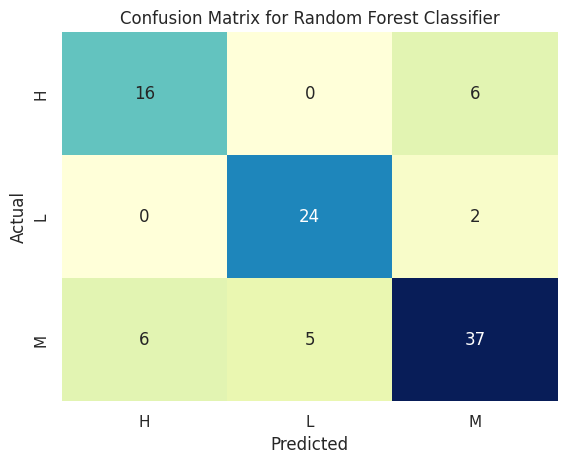

In [ ]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)
rf_predictions = rf_classifier.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_predictions)
print(f"Accuracy: {rf_accuracy}\n")

confusion_mat_rf = confusion_matrix(y_test, rf_predictions)
print("Confusion Matrix:")
print(confusion_mat_rf)

classification_rep_rf = classification_report(y_test, rf_predictions)
print("\nClassification Report:")
print(classification_rep_rf)

sns.heatmap(confusion_mat_rf, annot=True, fmt="d", cmap="YlGnBu", cbar=False,
            xticklabels=rf_classifier.classes_, yticklabels=rf_classifier.classes_)
plt.title('Confusion Matrix for Random Forest Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Decision Tree

Decision Tree Accuracy: 0.7188
Confusion Matrix:
[[13  0  9]
 [ 0 23  3]
 [ 8  7 33]]
Classification Report:
              precision    recall  f1-score   support

           H       0.62      0.59      0.60        22
           L       0.77      0.88      0.82        26
           M       0.73      0.69      0.71        48

    accuracy                           0.72        96
   macro avg       0.71      0.72      0.71        96
weighted avg       0.72      0.72      0.72        96



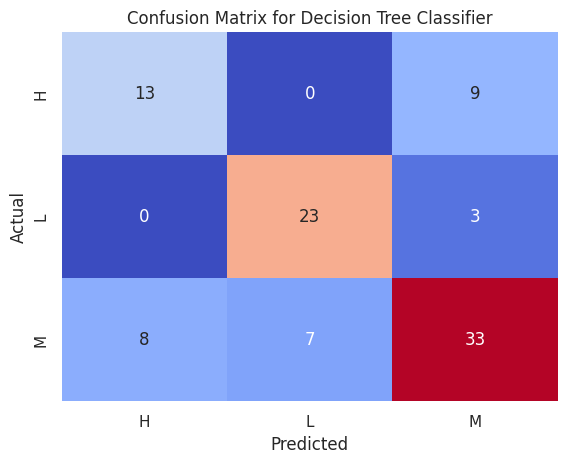

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"Decision Tree Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="coolwarm", cbar=False,
            xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# KNN

KNN Accuracy: 0.7604
Confusion Matrix:
[[16  0  6]
 [ 0 24  2]
 [ 8  7 33]]
Classification Report:
              precision    recall  f1-score   support

           H       0.67      0.73      0.70        22
           L       0.77      0.92      0.84        26
           M       0.80      0.69      0.74        48

    accuracy                           0.76        96
   macro avg       0.75      0.78      0.76        96
weighted avg       0.76      0.76      0.76        96



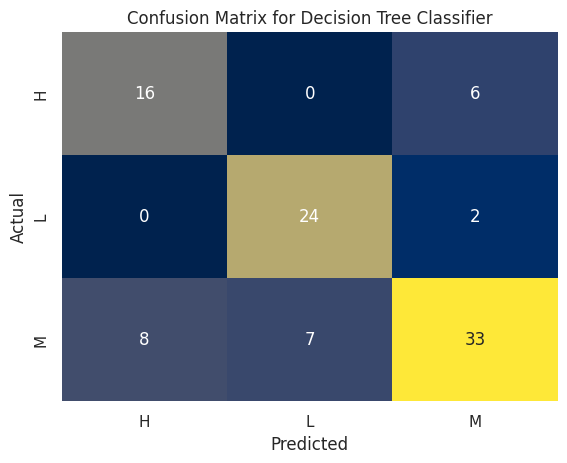

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=20)
knn_model.fit(X_train, y_train)

y_pred = knn_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
classification_rep = classification_report(y_test, y_pred)

print(f"KNN Accuracy: {accuracy:.4f}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(classification_rep)

sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="cividis", cbar=False,
            xticklabels=dt_model.classes_, yticklabels=dt_model.classes_)
plt.title('Confusion Matrix for Decision Tree Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curves

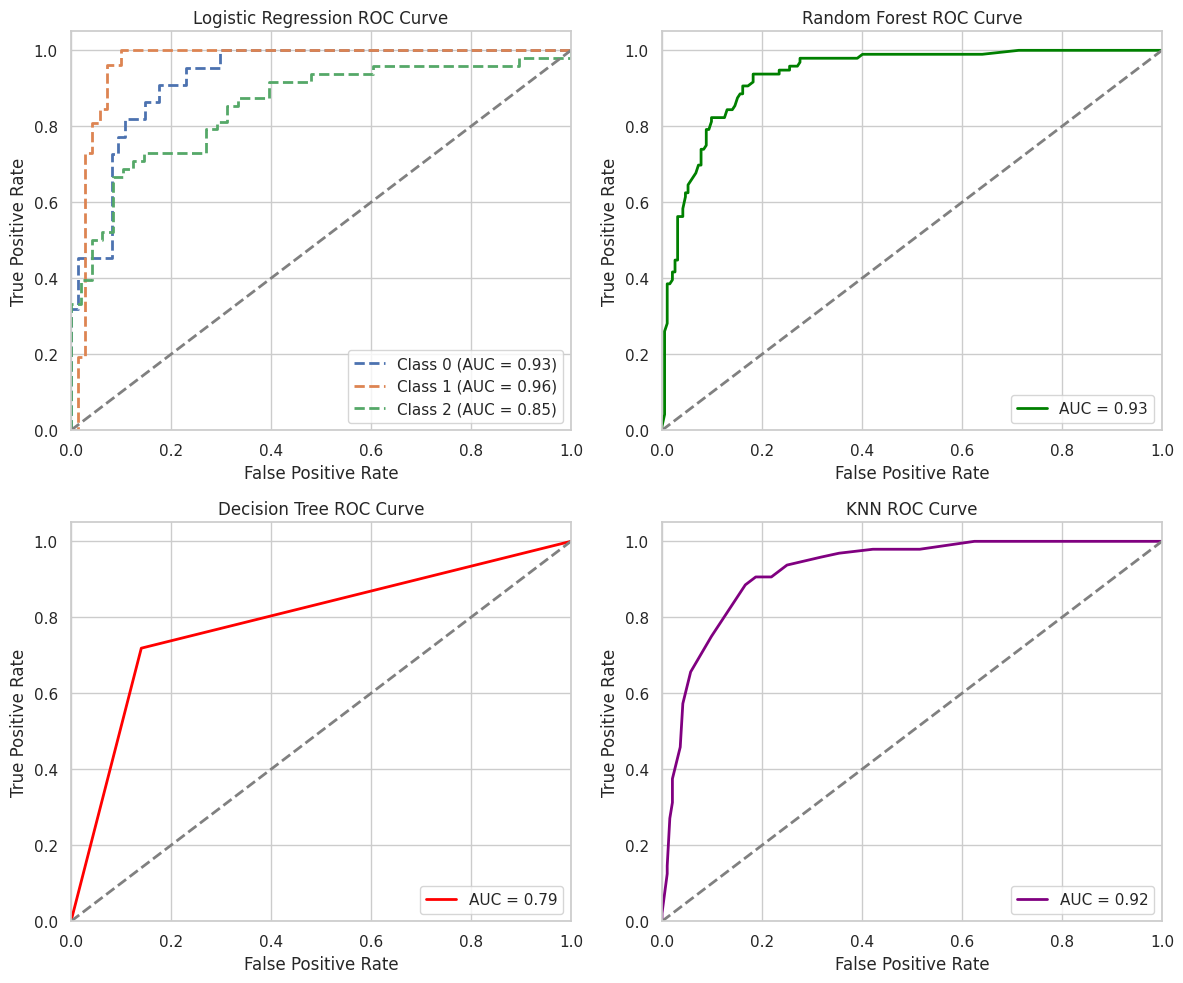

In [ ]:
y_test_one_hot = label_binarize(y_test, classes=logreg_model.classes_)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Logistic Regression ROC
axes[0, 0].set_title('Logistic Regression ROC Curve')
for i in range(len(logreg_model.classes_)):
    fpr, tpr, _ = roc_curve(y_test_one_hot[:, i], logreg_model.predict_proba(X_test)[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0, 0].plot(fpr, tpr, lw=2, label=f'Class {i} (AUC = {roc_auc:.2f})', linestyle='--')
axes[0, 0].plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
axes[0, 0].set_xlim([0.0, 1.0])
axes[0, 0].set_ylim([0.0, 1.05])
axes[0, 0].set_xlabel('False Positive Rate')
axes[0, 0].set_ylabel('True Positive Rate')
axes[0, 0].legend(loc="lower right")

# Random Forest ROC
axes[0, 1].set_title('Random Forest ROC Curve')
fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), rf_classifier.predict_proba(X_test).ravel())
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='green', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[0, 1].plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend(loc="lower right")

# Decision Tree ROC
axes[1, 0].set_title('Decision Tree ROC Curve')
fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), dt_model.predict_proba(X_test).ravel())
roc_auc = auc(fpr, tpr)
axes[1, 0].plot(fpr, tpr, color='red', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1, 0].plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
axes[1, 0].set_xlim([0.0, 1.0])
axes[1, 0].set_ylim([0.0, 1.05])
axes[1, 0].set_xlabel('False Positive Rate')
axes[1, 0].set_ylabel('True Positive Rate')
axes[1, 0].legend(loc="lower right")

# KNN ROC
axes[1, 1].set_title('KNN ROC Curve')
fpr, tpr, _ = roc_curve(y_test_one_hot.ravel(), knn_model.predict_proba(X_test).ravel())
roc_auc = auc(fpr, tpr)
axes[1, 1].plot(fpr, tpr, color='purple', lw=2, label=f'AUC = {roc_auc:.2f}')
axes[1, 1].plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--')
axes[1, 1].set_xlim([0.0, 1.0])
axes[1, 1].set_ylim([0.0, 1.05])
axes[1, 1].set_xlabel('False Positive Rate')
axes[1, 1].set_ylabel('True Positive Rate')
axes[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()

# K-Means Clustering

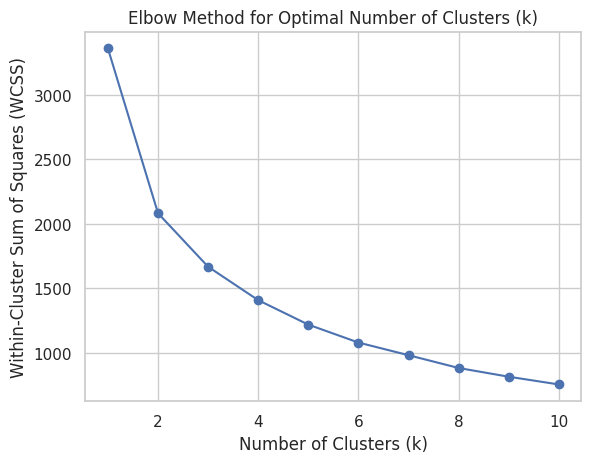

In [ ]:
X_kmeans = Data
scaler_kmeans = StandardScaler()
X_scaled_kmeans = scaler_kmeans.fit_transform(X_kmeans)

# PCA
pca_kmeans = PCA(n_components=2)
X_pca_kmeans = pca_kmeans.fit_transform(X_scaled_kmeans)

# t-SNE
tsne_kmeans = TSNE(n_components=2, random_state=0)
X_tsne_kmeans = tsne_kmeans.fit_transform(X_scaled_kmeans)

# Elbow Method
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=0)
    kmeans.fit(X_scaled_kmeans)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method for Optimal Number of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Within-Cluster Sum of Squares (WCSS)')
plt.show()



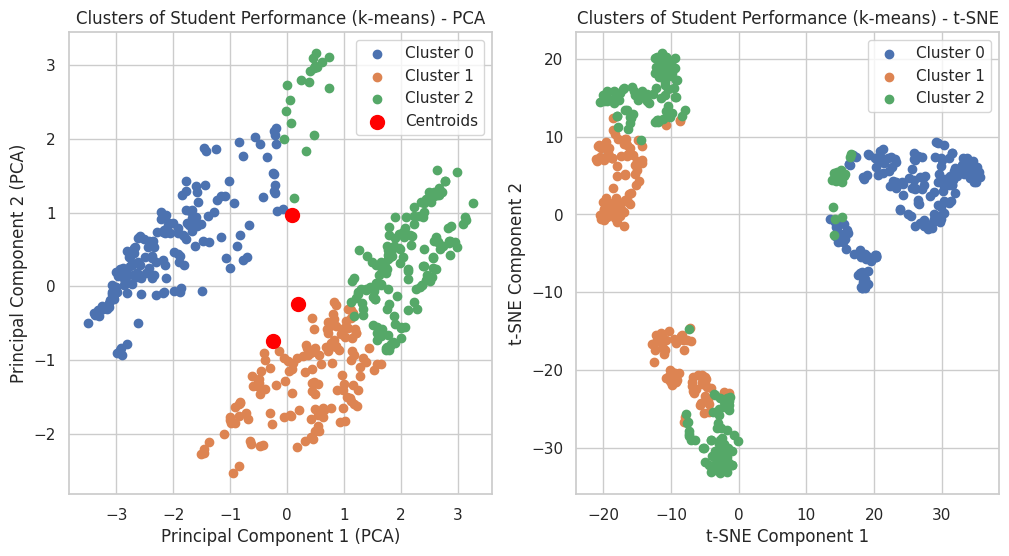

In [ ]:
optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=300, n_init=10, random_state=0)
kmeans.fit(X_scaled_kmeans)

df['Cluster'] = kmeans.labels_

plt.figure(figsize=(12, 6))

# Plot using PCA
plt.subplot(1, 2, 1)
for cluster_label in range(optimal_k):
    plt.scatter(X_pca_kmeans[df['Cluster'] == cluster_label, 0],
                X_pca_kmeans[df['Cluster'] == cluster_label, 1], label=f'Cluster {cluster_label}')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s=100, c='red', label='Centroids')
plt.title('Clusters of Student Performance (k-means) - PCA')
plt.xlabel('Principal Component 1 (PCA)')
plt.ylabel('Principal Component 2 (PCA)')
plt.legend()

# Plot using t-SNE
plt.subplot(1, 2, 2)
for cluster_label in range(optimal_k):
    plt.scatter(X_tsne_kmeans[df['Cluster'] == cluster_label, 0],
                X_tsne_kmeans[df['Cluster'] == cluster_label, 1], label=f'Cluster {cluster_label}')
plt.title('Clusters of Student Performance (k-means) - t-SNE')
plt.xlabel('t-SNE Component 1')
plt.ylabel('t-SNE Component 2')
plt.legend()

plt.show()

# Neural Network

In [ ]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(X, y_encoded, test_size=0.20, random_state=42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(len(label_encoder.classes_), activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history = model.fit(X_train_nn, y_train_nn, epochs=50, batch_size=32, validation_data=(X_test_nn, y_test_nn))

nn_predictions = model.predict(X_test_nn).argmax(axis=1)

nn_accuracy = accuracy_score(y_test_nn, nn_predictions)
print(f"Accuracy: {nn_accuracy}")

classification_rep_nn = classification_report(y_test_nn, nn_predictions)
print("Classification Report:")
print(classification_rep_nn)

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.4635 - loss: 1.0572 - val_accuracy: 0.6562 - val_loss: 0.9215
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5391 - loss: 0.9079 - val_accuracy: 0.6771 - val_loss: 0.8176
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6354 - loss: 0.8045 - val_accuracy: 0.7083 - val_loss: 0.7340
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6745 - loss: 0.7277 - val_accuracy: 0.7708 - val_loss: 0.6632
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6927 - loss: 0.6777 - val_accuracy: 0.7917 - val_loss: 0.6129
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7188 - loss: 0.6425 - val_accuracy: 0.7812 - val_loss: 0.5924
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7240 - loss: 0.6178 - val_accuracy: 0.7812 - val_loss: 0.5617
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7240 - loss: 0.6012 - val_accuracy: 0.7812 - val_loss

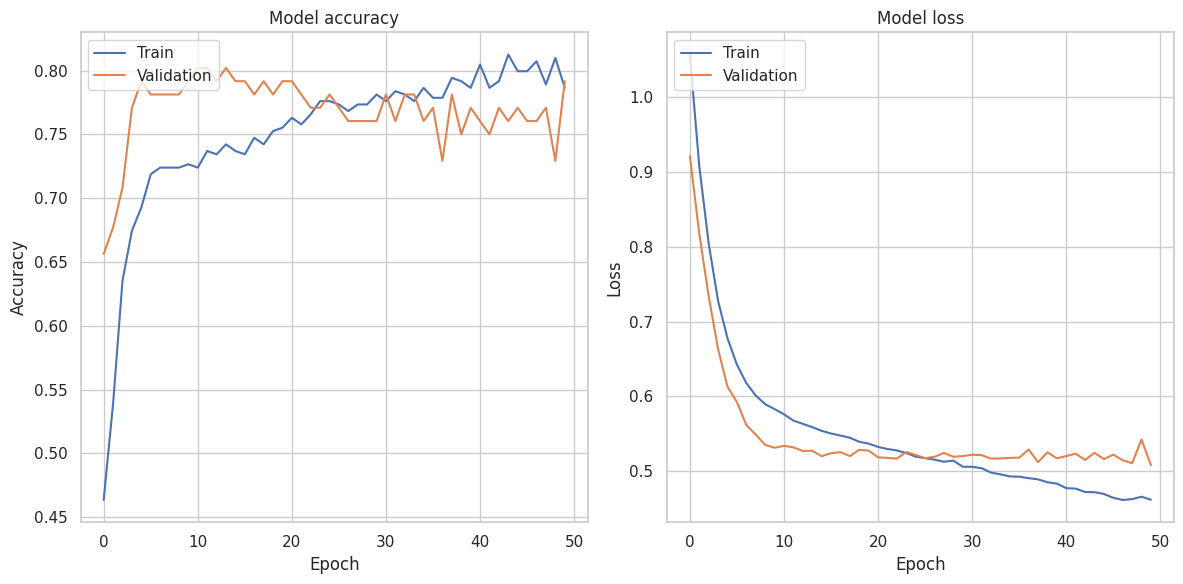

In [ ]:
# Accuracy values
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'], loc='upper left')

# Loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()
